 x³ + 3x² − 24x + 1 = 0 на отрезке [0, 1]
F(0) = 1.000000
F(1) = -19.000000
F''(0) = 6.000000
F''(1) = 12.000000

F(0)·F''(0) > 0 → c = a = 0
Начальное приближение для метода хорд: x₀ = b = 1
Начальное приближение для метода касательных: x_tan = c = 0

Результаты комбинированного метода:
----------------------------------------
Количество итераций: 3
Приближённое значение корня: 0.0418891852
Достигнутая точность: 1.19e-07

F(корень) = -0.0000028298
|F(корень)| = 2.83e-06

Таблица итераций:
----------------------------------------------------------------------
 Итерация  |    x_n (касат.)    |     x_n (хорд)     |   Погрешность  
----------------------------------------------------------------------
    0      |    0.0000000000    |    1.0000000000    |    5.00e-01    
    1      |    0.0416666667    |    0.0500000000    |    4.17e-03    
    2      |    0.0418890595    |    0.0419331167    |    2.20e-05    
    3      |    0.0418890660    |    0.0418893044    |    1.19e-07    
--------

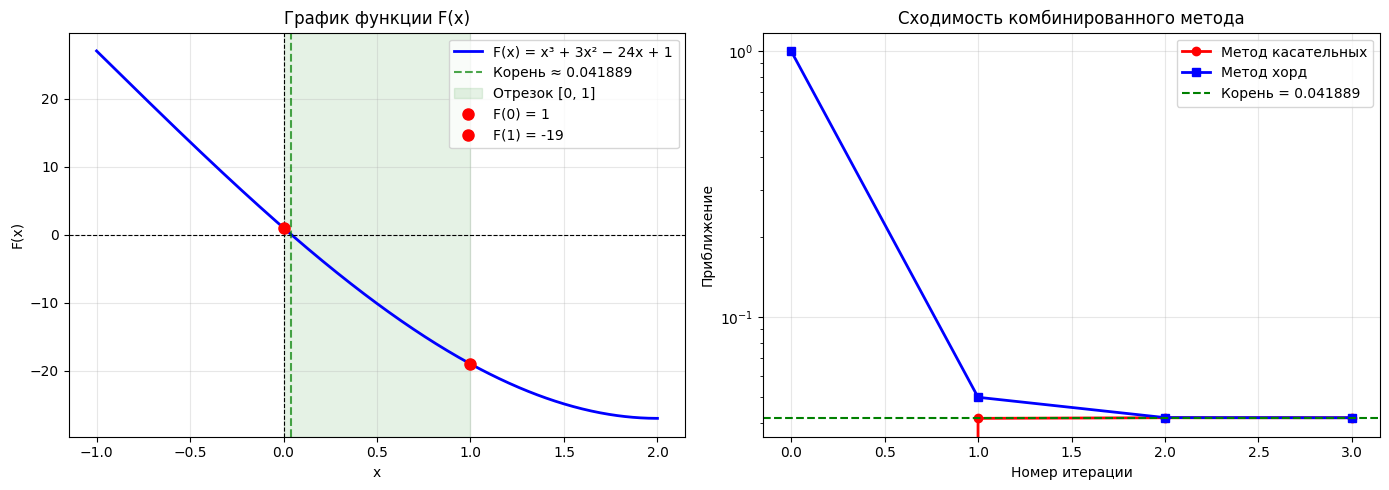

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def f_prime(x):
    return 3*x**2 + 6*x - 24

def f_double_prime(x):
    return 6*x + 6

a, b = 0, 1

Fa, Fb = f(a), f(b)
Fd2a, Fd2b = f_double_prime(a), f_double_prime(b)

print(" x³ + 3x² − 24x + 1 = 0 на отрезке [0, 1]")
print(f"F(0) = {Fa:.6f}")
print(f"F(1) = {Fb:.6f}")
print(f"F''(0) = {Fd2a:.6f}")
print(f"F''(1) = {Fd2b:.6f}")
print()

if Fa * Fd2a > 0:
    c = a
    x0_chord = b
    print("F(0)·F''(0) > 0 → c = a = 0")
    print("Начальное приближение для метода хорд: x₀ = b = 1")
else:
    c = b
    x0_chord = a
    print("F(1)·F''(1) > 0 → c = b = 1")
    print("Начальное приближение для метода хорд: x₀ = a = 0")

print(f"Начальное приближение для метода касательных: x_tan = c = {c}")
print()

def combined_method(f, f_prime, a, b, eps=1e-6, max_iter=100):
    if f(a) * f_double_prime(a) > 0:
        c = a
        x_tan = a
        x_chord = b
    else:
        c = b
        x_tan = b
        x_chord = a
    
    history_tan = [x_tan]
    history_chord = [x_chord]
    
    for i in range(max_iter):
        x_tan_new = x_tan - f(x_tan) / f_prime(x_tan)
        x_chord_new = (c * f(x_chord) - x_chord * f(c)) / (f(x_chord) - f(c))
        
        history_tan.append(x_tan_new)
        history_chord.append(x_chord_new)
        
        root_approx = (x_tan_new + x_chord_new) / 2
        error = abs(x_tan_new - x_chord_new) / 2
        
        if error < eps:
            return root_approx, i + 1, history_tan, history_chord, error
        
        x_tan, x_chord = x_tan_new, x_chord_new
    
    return root_approx, max_iter, history_tan, history_chord, error

root, n_iter, hist_tan, hist_chord, final_error = combined_method(f, f_prime, a, b, eps=1e-6)

print("Результаты комбинированного метода:")
print("-" * 40)
print(f"Количество итераций: {n_iter}")
print(f"Приближённое значение корня: {root:.10f}")
print(f"Достигнутая точность: {final_error:.2e}")
print()

F_root = f(root)
print(f"F(корень) = {F_root:.10f}")
print(f"|F(корень)| = {abs(F_root):.2e}")
print()

print("Таблица итераций:")
print("-" * 70)
print(f"{'Итерация':^10} | {'x_n (касат.)':^18} | {'x_n (хорд)':^18} | {'Погрешность':^15}")
print("-" * 70)

for i in range(len(hist_tan)):
    if i < len(hist_chord):
        x_t = hist_tan[i]
        x_c = hist_chord[i]
        if i > 0:
            error = abs(x_t - x_c) / 2
        else:
            error = abs(b - a) / 2
        print(f"{i:^10} | {x_t:^18.10f} | {x_c:^18.10f} | {error:^15.2e}")
print("-" * 70)
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_plot = np.linspace(-1, 2, 500)
y_plot = f(x_plot)

axes[0].plot(x_plot, y_plot, 'b-', linewidth=2, label='F(x) = x³ + 3x² − 24x + 1')
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0, color='k', linestyle='--', linewidth=0.8)
axes[0].axvline(x=root, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Корень ≈ {root:.6f}')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].set_title('График функции F(x)')
axes[0].axvspan(0, 1, alpha=0.1, color='green', label='Отрезок [0, 1]')
axes[0].plot(0, f(0), 'ro', markersize=8, label='F(0) = 1')
axes[0].plot(1, f(1), 'ro', markersize=8, label='F(1) = -19')
axes[0].legend(loc='best')

iterations = range(len(hist_tan))

axes[1].semilogy(iterations, hist_tan, 'r-o', linewidth=2, markersize=6, label='Метод касательных')
axes[1].semilogy(iterations, hist_chord, 'b-s', linewidth=2, markersize=6, label='Метод хорд')
axes[1].axhline(y=root, color='g', linestyle='--', linewidth=1.5, label=f'Корень = {root:.6f}')
axes[1].set_xlabel('Номер итерации')
axes[1].set_ylabel('Приближение')
axes[1].set_title('Сходимость комбинированного метода')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()
